# Notebook 06 - Interpretability

Notebook này thực hiện phân tích khả năng giải thích của mô hình dự đoán Digital Burnout Level trên dataset sinh viên Việt Nam.

Sau khi lựa chọn mô hình tối ưu trong Notebook 05, bước Interpretability được thực hiện nhằm khám phá:

- Những đặc trưng nào ảnh hưởng nhiều nhất đến Digital Burnout.
- Mức độ đóng góp của từng đặc trưng vào dự đoán mô hình.
- Sự nhất quán giữa kết quả Machine Learning và bộ chỉ số Digital Burnout Indicator (DBI).
- Cách giải thích nguy cơ burnout cho từng cá nhân.

# 0. Set Up

Thiết lập môi trường phân tích, import các thư viện cần thiết và khai báo đường dẫn sử dụng trong Notebook.

In [1]:
# Import libraries

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from IPython.display import display

print(
    "Đã import toàn bộ thư viện cần thiết."
)

Đã import toàn bộ thư viện cần thiết.


In [2]:
# Đường dẫn 

model_path = "../../models/vietnam_dataset"

print(
    f"Model path: {model_path}"
)

Model path: ../../models/vietnam_dataset


In [3]:
# Kiểm tra file model

os.listdir(
    model_path
)

['best_model.joblib',
 'classification_reports.joblib',
 'confusion_matrices.joblib',
 'logistic_regression.joblib',
 'model_performance.csv',
 'random_forest.joblib',
 'stacking_classifier.joblib',
 'voting_classifier.joblib',
 'xgboost.joblib',
 'X_validation.joblib',
 'y_validation.joblib']

# 1. Load Model and Validation Data

Nạp lại các mô hình đã được huấn luyện trong Notebook 05 cùng với tập dữ liệu validation để thực hiện phân tích khả năng giải thích mô hình.

Các thành phần được load bao gồm:

- Best Model: Voting Classifier - Được lựa chọn làm mô hình dự đoán Digital Burnout Level cuối cùng.
- Explainable Model: XGBoost - Được sử dụng cho phân tích SHAP nhằm xác định mức độ ảnh hưởng của các đặc trưng.
- Validation Dataset:
    - X_validation.
    - y_validation.

Việc tách riêng mô hình dự đoán và mô hình giải thích giúp đảm bảo vừa duy trì hiệu suất dự đoán, vừa có khả năng phân tích nguyên nhân ảnh hưởng đến kết quả dự đoán.

In [4]:
# Load best model

best_model = joblib.load(
    os.path.join(
        model_path,
        "best_model.joblib"
    )
)

# Load XGBoost model dùng cho SHAP

xgboost_model = joblib.load(
    os.path.join(
        model_path,
        "xgboost.joblib"
    )
)

print(
    "Đã load mô hình thành công."
)

Đã load mô hình thành công.


In [5]:
# Load validation features

X_validation = joblib.load(
    os.path.join(
        model_path,
        "X_validation.joblib"
    )
)

# Load validation target

y_validation = joblib.load(
    os.path.join(
        model_path,
        "y_validation.joblib"
    )
)

print(
    "Đã load validation dataset."
)

Đã load validation dataset.


In [6]:
# Kiểm tra kích thước validation dataset

print(
    f"X_validation shape: {X_validation.shape}"
)

print(
    f"y_validation shape: {y_validation.shape}"
)

X_validation shape: (98, 15)
y_validation shape: (98,)


In [7]:
# Kiểm tra loại model

print(
    "Best Model:"
)

print(
    type(best_model)
)

print(
    "\nExplainable Model:"
)

print(
    type(xgboost_model)
)

Best Model:
<class 'sklearn.pipeline.Pipeline'>

Explainable Model:
<class 'sklearn.pipeline.Pipeline'>


In [8]:
# Test prediction

sample_prediction = best_model.predict(
    X_validation.head()
)

print(
    "Sample prediction:"
)

print(
    sample_prediction
)

Sample prediction:
[1 1 1 1 2]


# 2. Global Interpretability

Phân tích mức độ ảnh hưởng tổng thể của các đặc trưng đầu vào đối với quyết định dự đoán Digital Burnout Level của mô hình Machine Learning.

Global Interpretability giúp xác định:

- Feature nào có ảnh hưởng lớn nhất đến kết quả dự đoán.
- Các yếu tố hành vi sử dụng thiết bị, trạng thái tâm lý và hiệu suất học tập đóng vai trò như thế nào trong Digital Burnout.
- Sự phù hợp giữa kết quả Machine Learning và bộ chỉ số Digital Burnout Indicator (DBI).

Trong nghiên cứu này:

- Voting Classifier được sử dụng làm mô hình dự đoán cuối cùng.
- XGBoost được sử dụng làm mô hình giải thích do khả năng tương thích tốt với SHAP.

SHAP (SHapley Additive exPlanations) được áp dụng để đo lường mức độ đóng góp của từng feature vào kết quả dự đoán.

## 2.1 Prepare XGBoost Model for SHAP

Chuẩn bị mô hình XGBoost đã huấn luyện để thực hiện phân tích SHAP.

XGBoost model được load từ kết quả huấn luyện ở Notebook 05.

Do mô hình được xây dựng dưới dạng Pipeline gồm:

1. Preprocessing Pipeline.
2. XGBoost Classifier.

Cần tách riêng hai thành phần này để:

- Chuyển đổi dữ liệu validation về đúng dạng mà mô hình XGBoost sử dụng.
- Trích xuất feature names sau preprocessing.
- Đưa dữ liệu đã xử lý vào SHAP Explainer.

In [9]:
# Kiểm tra cấu trúc XGBoost pipeline

xgboost_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['daily_screen_time',
                                                   'social_media_hours',
                                                   'doomscrolling_duration',
                                                   'late_night_device_usage',
                                                   'notification_count',
                                                   'smartphone_unlocks',
                                                   'app_switch_frequency',
                                                   'concentration_score',
                                                   'distraction_frequency',
                                                   'focus_sessions',
                                                   'deep_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [12]:
# Tách preprocessing pipeline

xgb_preprocessor = xgboost_model.named_steps[
    "preprocessor"
]

# Tách XGBoost model

xgb_classifier = xgboost_model.named_steps[
    "model"
]

print(
    "Đã tách preprocessing pipeline và XGBoost model."
)

Đã tách preprocessing pipeline và XGBoost model.


In [13]:
# Chuyển đổi validation dataset

X_validation_transformed = xgb_preprocessor.transform(
    X_validation
)

print(
    "Shape sau preprocessing:"
)

print(
    X_validation_transformed.shape
)

Shape sau preprocessing:
(98, 15)


In [14]:
# Lấy tên feature

feature_names = xgb_preprocessor.get_feature_names_out()

feature_table = pd.DataFrame({
    "Feature": feature_names
})

print(
    f"Số lượng feature sau preprocessing: {len(feature_names)}"
)

display(
    feature_table
)

Số lượng feature sau preprocessing: 15


,Feature
0,numerical__daily_screen_time
1,numerical__social_media_hours
2,numerical__doomscrolling_duration
3,numerical__late_night_device_usage
4,numerical__notification_count
5,numerical__smartphone_unlocks
6,numerical__app_switch_frequency
7,numerical__concentration_score
8,numerical__distraction_frequency
9,numerical__focus_sessions


## 2.2 Compute SHAP Values

Tính toán SHAP (SHapley Additive exPlanations) nhằm định lượng mức độ đóng góp của từng đặc trưng đối với kết quả dự đoán của mô hình XGBoost.

Trong nghiên cứu này, SHAP TreeExplainer được sử dụng vì XGBoost thuộc nhóm mô hình cây quyết định (Tree-based Model).

Đối với mỗi quan sát, SHAP sẽ:

- Xác định mức độ đóng góp của từng feature.
- Giải thích tại sao mô hình đưa ra dự đoán tương ứng.
- Làm cơ sở cho các phân tích Global Interpretability và Local Interpretability.

In [15]:
# Khởi tạo SHAP Tree Explainer

explainer = shap.TreeExplainer(
    xgb_classifier
)

print(
    "Đã khởi tạo SHAP TreeExplainer."
)

Đã khởi tạo SHAP TreeExplainer.


In [16]:
# Tính SHAP values

shap_values = explainer.shap_values(
    X_validation_transformed
)

print(
    "Đã tính toán SHAP values."
)

Đã tính toán SHAP values.


In [17]:
# Kiểm tra kiểu dữ liệu SHAP

print(
    type(shap_values)
)

if isinstance(shap_values, list):

    print(
        f"Số lớp: {len(shap_values)}"
    )

    for i, values in enumerate(shap_values):

        print(
            f"Class {i}: {values.shape}"
        )

else:

    print(
        shap_values.shape
    )

<class 'numpy.ndarray'>
(98, 15, 3)


## 2.3 SHAP Summary Plot

Trực quan hóa mức độ ảnh hưởng tổng thể của các đặc trưng đến kết quả dự đoán của mô hình XGBoost thông qua SHAP Summary Plot.

Do bài toán được xây dựng dưới dạng phân loại đa lớp (Multi-class Classification), SHAP sẽ tính toán giá trị đóng góp của từng đặc trưng đối với từng lớp dự đoán.

Trong nghiên cứu này, biến mục tiêu được mã hóa thành ba lớp:

- Class 0: Low Digital Burnout
- Class 1: Moderate Digital Burnout
- Class 2: High Digital Burnout

Do đó, các biểu đồ SHAP được trình bày theo từng lớp dự đoán (Class 0, Class 1 và Class 2).


In [19]:
# Hiển thị các lớp của mô hình

class_ids = xgb_classifier.classes_

print(
    "Classes của mô hình:"
)

print(
    class_ids
)

Classes của mô hình:
[0 1 2]



SHAP Summary Plot - Class 0


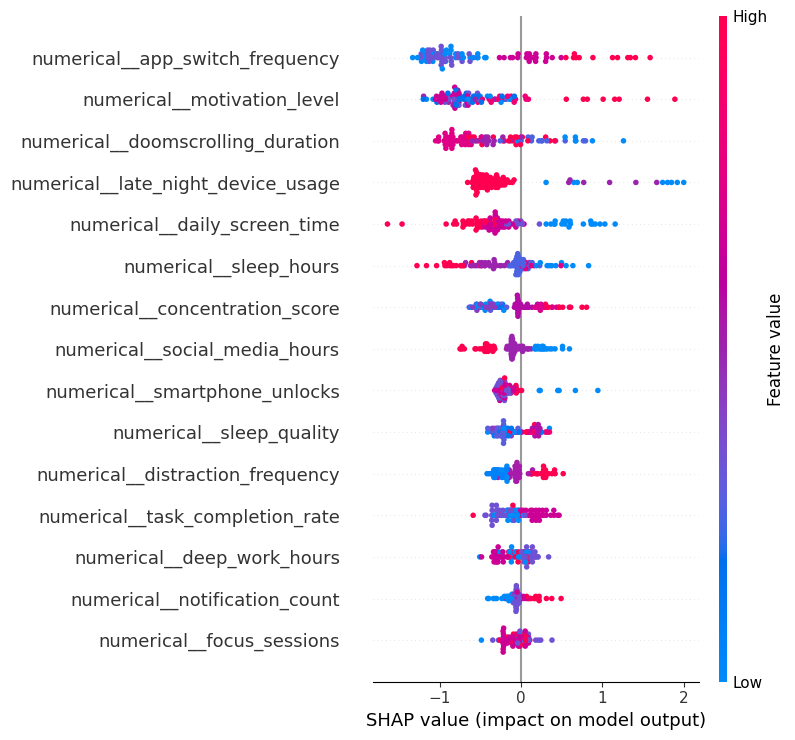


SHAP Summary Plot - Class 1


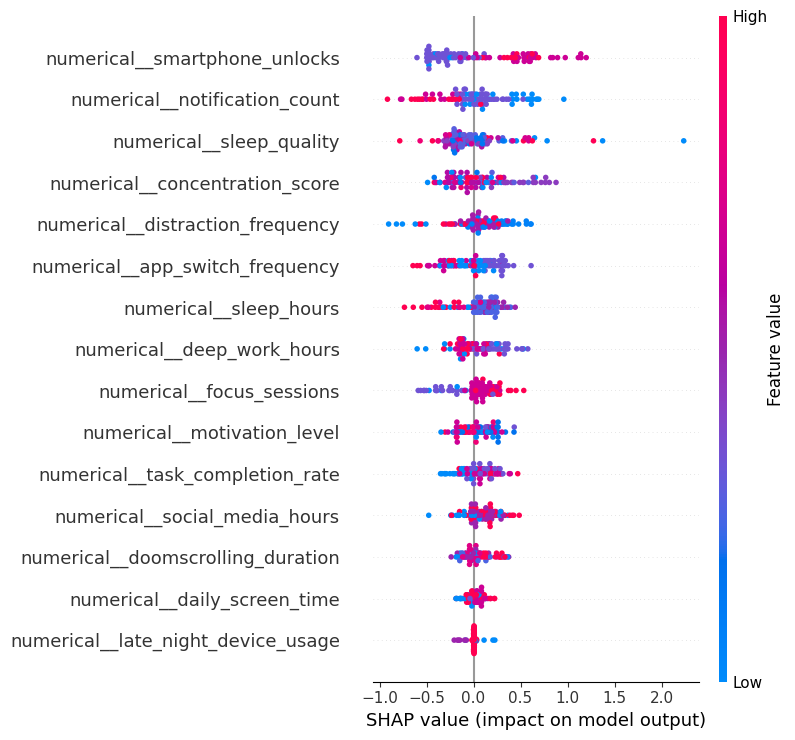


SHAP Summary Plot - Class 2


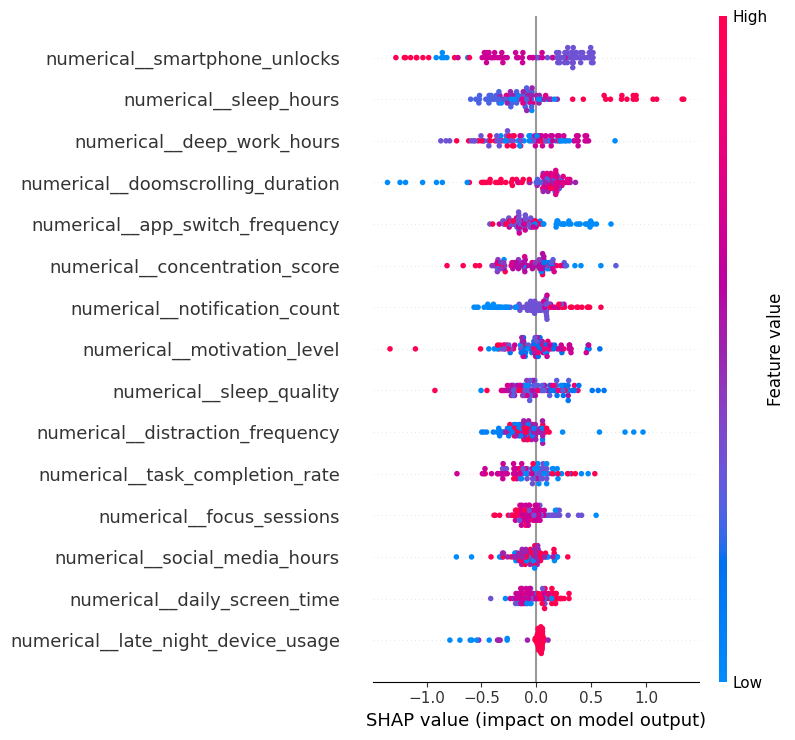

In [20]:
# SHAP Summary Plot cho từng lớp

for class_index in class_ids:

    print(
        f"\nSHAP Summary Plot - Class {class_index}"
    )

    shap.summary_plot(

        shap_values[:, :, class_index],

        X_validation_transformed,

        feature_names=feature_names,

        show=True

    )

Kết quả SHAP Summary Plot cho thấy mô hình XGBoost đã xác định được mức độ ảnh hưởng của từng đặc trưng đối với từng lớp dự đoán (Class 0, Class 1 và Class 2).

Các đặc trưng có mức đóng góp cao nhất khác nhau giữa các lớp, cho thấy mô hình không dựa trên một yếu tố duy nhất mà khai thác nhiều khía cạnh hành vi sử dụng thiết bị và học tập để phân biệt các mức Digital Burnout.

Những kết quả này là cơ sở để tiếp tục phân tích mức độ quan trọng của từng đặc trưng thông qua SHAP Feature Importance ở phần tiếp theo.

## 2.4 SHAP Feature Importance

Tổng hợp mức độ quan trọng của các đặc trưng dựa trên giá trị SHAP trung bình nhằm xác định những yếu tố có ảnh hưởng lớn nhất đến quyết định dự đoán của mô hình XGBoost.

Đối với bài toán phân loại đa lớp, giá trị SHAP tuyệt đối được lấy trung bình trên toàn bộ tập Validation và trên cả ba lớp dự đoán.

Giá trị SHAP trung bình càng lớn cho thấy đặc trưng càng có ảnh hưởng quan trọng đến kết quả dự đoán của mô hình.

In [22]:
# Tính giá trị SHAP trung bình

mean_shap = np.abs(
    shap_values
).mean(
    axis=(0, 2)
)

# Tạo bảng Feature Importance

shap_feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean_SHAP": mean_shap

})

# Sắp xếp giảm dần

shap_feature_importance = shap_feature_importance.sort_values(

    by="Mean_SHAP",

    ascending=False

).reset_index(
    drop=True
)

display(
    shap_feature_importance
)

,Feature,Mean_SHAP
0,numerical__app_switch_frequency,0.399335
1,numerical__smartphone_unlocks,0.347211
2,numerical__motivation_level,0.333562
3,numerical__doomscrolling_duration,0.297905
4,numerical__sleep_hours,0.278166
5,numerical__concentration_score,0.249486
6,numerical__sleep_quality,0.216336
7,numerical__daily_screen_time,0.214550
8,numerical__late_night_device_usage,0.211944
9,numerical__deep_work_hours,0.205566


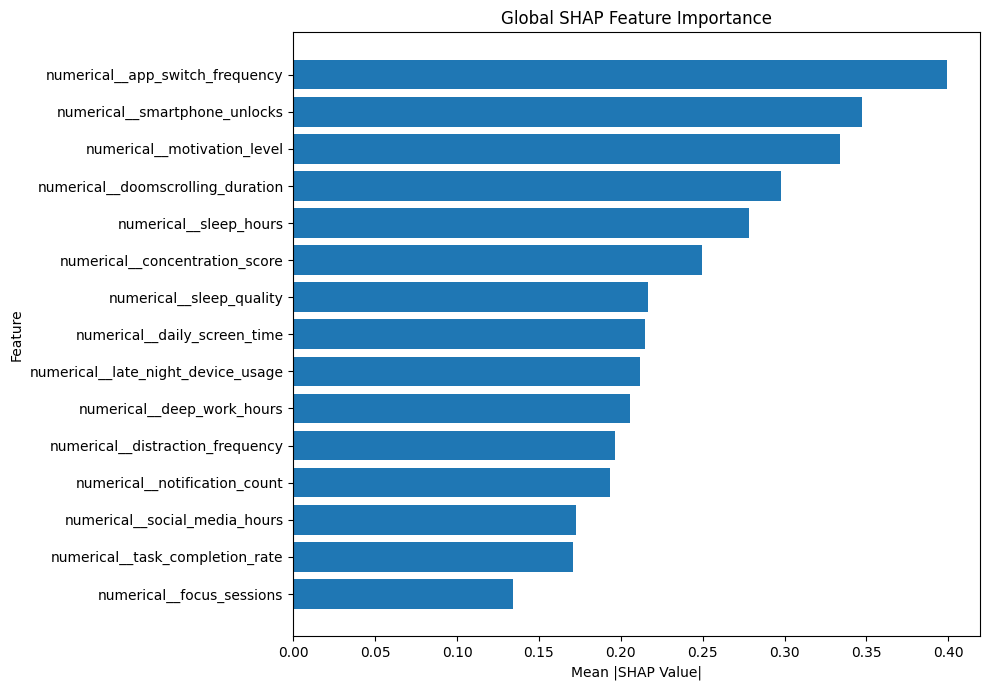

In [23]:
plt.figure(
    figsize=(10, 7)
)

plt.barh(

    shap_feature_importance["Feature"],

    shap_feature_importance["Mean_SHAP"]

)

plt.gca().invert_yaxis()

plt.xlabel(
    "Mean |SHAP Value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

plt.show()

## 2.5 SHAP Dependence Analysis

Phân tích mối quan hệ giữa giá trị của từng đặc trưng và mức độ đóng góp của đặc trưng đó vào kết quả dự đoán của mô hình thông qua SHAP Dependence Plot.

Các đặc trưng có giá trị SHAP trung bình cao nhất được lựa chọn để trực quan hóa.

Đối với mỗi đặc trưng, SHAP Dependence Plot biểu diễn:

- Giá trị của đặc trưng trên trục hoành.
- Giá trị SHAP trên trục tung.
- Mức độ ảnh hưởng của đặc trưng đến dự đoán của mô hình.

Qua đó có thể quan sát xu hướng ảnh hưởng của từng đặc trưng và hỗ trợ diễn giải hành vi của mô hình.

In [25]:
# Lấy Top 5 Feature quan trọng nhất

top_features = shap_feature_importance.head(
    5
)["Feature"].tolist()

print(
    "Top SHAP Features:"
)

display(
    top_features
)

Top SHAP Features:


['numerical__app_switch_frequency',
 'numerical__smartphone_unlocks',
 'numerical__motivation_level',
 'numerical__doomscrolling_duration',
 'numerical__sleep_hours']

In [26]:
# SHAP trung bình của 3 lớp

global_shap = shap_values.mean(
    axis=2
)


Dependence Plot: numerical__app_switch_frequency


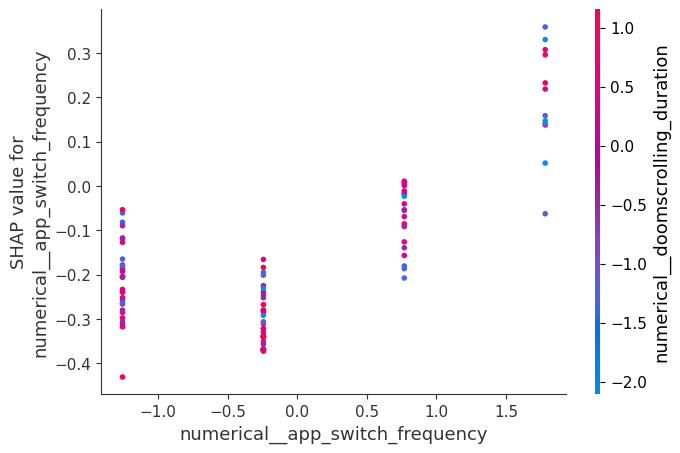


Dependence Plot: numerical__smartphone_unlocks


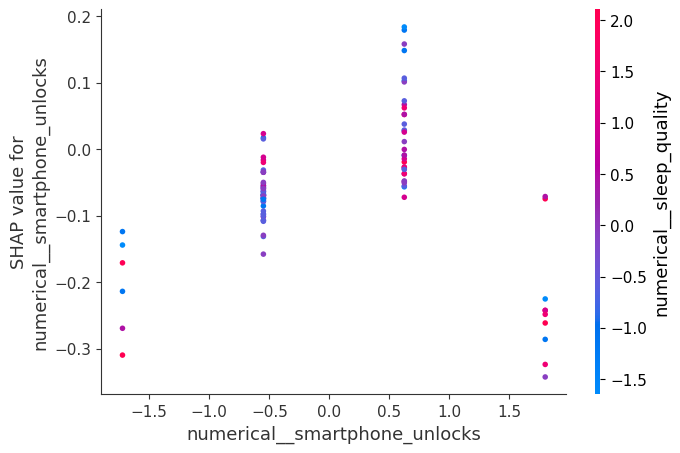


Dependence Plot: numerical__motivation_level


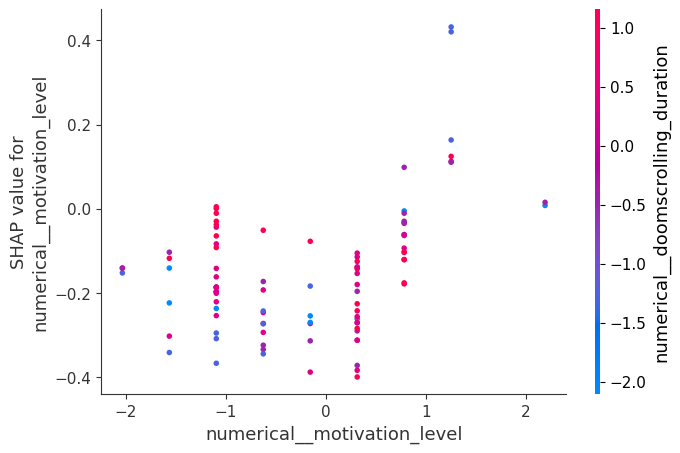


Dependence Plot: numerical__doomscrolling_duration


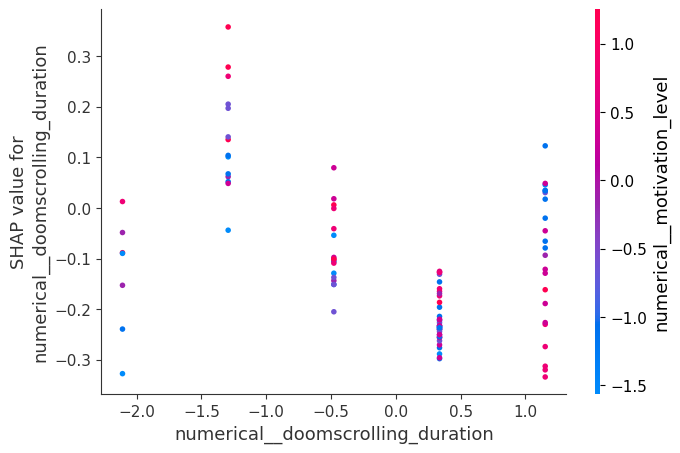


Dependence Plot: numerical__sleep_hours


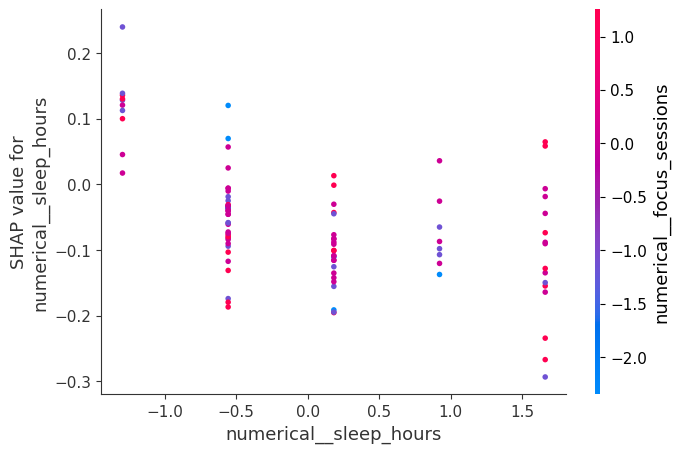

In [27]:
# SHAP Dependence Plot

for feature in top_features:

    print(
        f"\nDependence Plot: {feature}"
    )

    shap.dependence_plot(

        feature,

        global_shap,

        X_validation_transformed,

        feature_names=feature_names,

        interaction_index="auto"

    )

Kết quả SHAP Dependence Analysis cho thấy các đặc trưng quan trọng có mức độ ảnh hưởng khác nhau đến quyết định của mô hình. Một số đặc trưng như **App Switch Frequency**, **Sleep Hours** và **Doomscrolling Duration** thể hiện xu hướng biến thiên rõ rệt giữa giá trị đặc trưng và giá trị SHAP, cho thấy mô hình đã học được mối quan hệ giữa các hành vi sử dụng thiết bị và mức độ Digital Burnout.

Bên cạnh đó, một số đặc trưng như **Smartphone Unlocks** có xu hướng ảnh hưởng phi tuyến hoặc chịu tác động của sự tương tác với các đặc trưng khác, phản ánh rằng mô hình XGBoost không chỉ dựa trên từng đặc trưng riêng lẻ mà còn khai thác mối quan hệ kết hợp giữa nhiều yếu tố hành vi để đưa ra dự đoán.

Kết quả này tiếp tục khẳng định khả năng diễn giải của mô hình ở mức độ toàn cục và tạo cơ sở cho việc phân tích từng quan sát cụ thể trong phần Local Interpretability.

# 3. Local Interpretability

Sau khi phân tích mức độ ảnh hưởng của các đặc trưng trên toàn bộ tập dữ liệu (Global Interpretability), phần này tập trung giải thích quyết định dự đoán của mô hình đối với từng quan sát cụ thể.

Thông qua SHAP Local Explanation, nghiên cứu xác định:

- Những đặc trưng nào đóng góp tích cực vào quyết định của mô hình.
- Những đặc trưng nào làm giảm xác suất dự đoán.
- Mức độ đóng góp của từng đặc trưng đối với kết quả dự đoán của từng sinh viên.

Kết quả giúp tăng tính minh bạch của mô hình và hỗ trợ giải thích nguyên nhân dẫn đến mức Digital Burnout được dự đoán cho từng trường hợp cụ thể.

## 3.1 Chuẩn bị mô hình và dữ liệu phân tích

Chuẩn bị dữ liệu đã tiền xử lý và đối tượng SHAP Explainer để phục vụ phân tích từng quan sát.

- Dữ liệu Validation sau tiền xử lý.
- SHAP Explainer.
- SHAP Values.

In [30]:
# Dữ liệu phục vụ Local Interpretability

X_local = X_validation_transformed

shap_local = shap_values

print(
    "Shape dữ liệu:"
)

print(
    X_local.shape
)

print(
    "Shape SHAP:"
)

print(
    shap_local.shape
)

Shape dữ liệu:
(98, 15)
Shape SHAP:
(98, 15, 3)


## 3.2 Lựa chọn quan sát phân tích

Lựa chọn một quan sát trong tập Validation để thực hiện phân tích Local Interpretability.

Quan sát được lựa chọn sẽ được sử dụng xuyên suốt các phần tiếp theo nhằm giải thích chi tiết quyết định dự đoán của mô hình thông qua giá trị SHAP.

Trong nghiên cứu này, quan sát đầu tiên của tập Validation được lựa chọn để đảm bảo khả năng tái lập kết quả.

In [31]:
# Chọn quan sát để phân tích

observation_index = 0

print(
    "Observation Index:"
)

print(
    observation_index
)

Observation Index:
0


In [32]:
# Hiển thị dữ liệu gốc của quan sát

selected_observation = X_validation.iloc[
    observation_index
]

display(
    selected_observation.to_frame(
        name="Value"
    )
)

,Value
daily_screen_time,4
social_media_hours,3
doomscrolling_duration,3
late_night_device_usage,4
notification_count,2
smartphone_unlocks,3
app_switch_frequency,1
concentration_score,7
distraction_frequency,3
focus_sessions,4


In [33]:
print(
    "Số đặc trưng của quan sát:"
)

print(
    len(selected_observation)
)

Số đặc trưng của quan sát:
15


## 3.3 Xác định lớp dự đoán

Xác định lớp dự đoán và xác suất dự đoán của mô hình đối với quan sát được lựa chọn.

Kết quả này sẽ được sử dụng để xác định đúng tập giá trị SHAP cần phân tích trong các bước tiếp theo.

In [34]:
# Dự đoán cho quan sát được lựa chọn

selected_prediction = xgboost_model.predict(

    X_validation.iloc[[observation_index]]

)[0]

print(
    "Predicted Class:"
)

print(
    selected_prediction
)

Predicted Class:
1


In [35]:
# Xác suất dự đoán

prediction_probability = xgboost_model.predict_proba(

    X_validation.iloc[[observation_index]]

)[0]


probability_table = pd.DataFrame({

    "Class": xgb_classifier.classes_,

    "Probability": prediction_probability

})


display(
    probability_table
)

,Class,Probability
0,0,0.000489
1,1,0.703200
2,2,0.296311


In [36]:
# Class cần giải thích

explained_class = selected_prediction

print(
    "Class được giải thích:"
)

print(
    explained_class
)

Class được giải thích:
1


## 3.4 Trích xuất mức độ đóng góp của feature

Trích xuất giá trị SHAP của từng đặc trưng đối với lớp dự đoán nhằm xác định mức độ và chiều hướng đóng góp của từng đặc trưng vào quyết định của mô hình.

Đối với quan sát đã lựa chọn, nghiên cứu sử dụng giá trị SHAP tương ứng với **lớp được mô hình dự đoán**.

Mỗi đặc trưng sẽ được biểu diễn bởi:

- Giá trị thực tế của đặc trưng.
- Giá trị SHAP.
- Chiều hướng đóng góp.
- Thứ hạng mức độ ảnh hưởng.

In [37]:
# SHAP của lớp được dự đoán

selected_shap = shap_values[
    observation_index,
    :,
    explained_class
]

print(
    "Số lượng SHAP Value:"
)

print(
    len(selected_shap)
)

Số lượng SHAP Value:
15


In [41]:
# Tạo bảng đóng góp của từng đặc trưng

feature_contribution = pd.DataFrame({
    "Feature": feature_names,
    "Feature Value": X_validation_transformed[
        observation_index
    ],
    "SHAP Value": selected_shap
})

# Xác định chiều hướng đóng góp

feature_contribution["Direction"] = np.where(
    feature_contribution["SHAP Value"] >= 0,
    "Positive",
    "Negative"
)

# Tính giá trị SHAP tuyệt đối

feature_contribution["Absolute SHAP"] = np.abs(
    feature_contribution["SHAP Value"]
)

# Sắp xếp theo mức độ ảnh hưởng

feature_contribution = feature_contribution.sort_values(
    by="Absolute SHAP",
    ascending=False
).reset_index(
    drop=True
)

# Thêm thứ hạng

feature_contribution.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(feature_contribution) + 1
    )
)

# Làm tròn số để hiển thị đẹp hơn

feature_contribution["Feature Value"] = feature_contribution[
    "Feature Value"
].round(4)

feature_contribution["SHAP Value"] = feature_contribution[
    "SHAP Value"
].round(4)

feature_contribution["Absolute SHAP"] = feature_contribution[
    "Absolute SHAP"
].round(4)

# Hiển thị kết quả

display(
    feature_contribution
)

,Rank,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
0,1,numerical__sleep_hours,1.6605,-0.7353,Negative,0.7353
1,2,numerical__smartphone_unlocks,0.6240,0.5919,Positive,0.5919
2,3,numerical__focus_sessions,1.2530,0.2712,Positive,0.2712
3,4,numerical__app_switch_frequency,-1.2566,-0.2589,Negative,0.2589
4,5,numerical__motivation_level,-1.0966,0.2520,Positive,0.2520
5,6,numerical__concentration_score,0.7153,0.2036,Positive,0.2036
6,7,numerical__social_media_hours,0.0360,0.1697,Positive,0.1697
7,8,numerical__notification_count,-0.1468,0.1544,Positive,0.1544
8,9,numerical__deep_work_hours,1.4043,-0.1049,Negative,0.1049
9,10,numerical__doomscrolling_duration,-0.4784,-0.0990,Negative,0.0990


## 3.5 Biểu đồ đóng góp của feature

Trực quan hóa mức độ và chiều hướng đóng góp của các đặc trưng đối với quyết định dự đoán của mô hình cho quan sát được lựa chọn.

Các đặc trưng được sắp xếp theo giá trị SHAP tuyệt đối giảm dần. Giá trị SHAP dương thể hiện đặc trưng góp phần làm tăng xác suất dự đoán của lớp hiện tại, trong khi giá trị SHAP âm thể hiện đặc trưng làm giảm xác suất dự đoán của lớp đó.

In [42]:
# Lấy 10 đặc trưng quan trọng nhất

top10_contribution = feature_contribution.head(
    10
)

display(
    top10_contribution
)

,Rank,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
0,1,numerical__sleep_hours,1.6605,-0.7353,Negative,0.7353
1,2,numerical__smartphone_unlocks,0.6240,0.5919,Positive,0.5919
2,3,numerical__focus_sessions,1.2530,0.2712,Positive,0.2712
3,4,numerical__app_switch_frequency,-1.2566,-0.2589,Negative,0.2589
4,5,numerical__motivation_level,-1.0966,0.2520,Positive,0.2520
5,6,numerical__concentration_score,0.7153,0.2036,Positive,0.2036
6,7,numerical__social_media_hours,0.0360,0.1697,Positive,0.1697
7,8,numerical__notification_count,-0.1468,0.1544,Positive,0.1544
8,9,numerical__deep_work_hours,1.4043,-0.1049,Negative,0.1049
9,10,numerical__doomscrolling_duration,-0.4784,-0.0990,Negative,0.0990


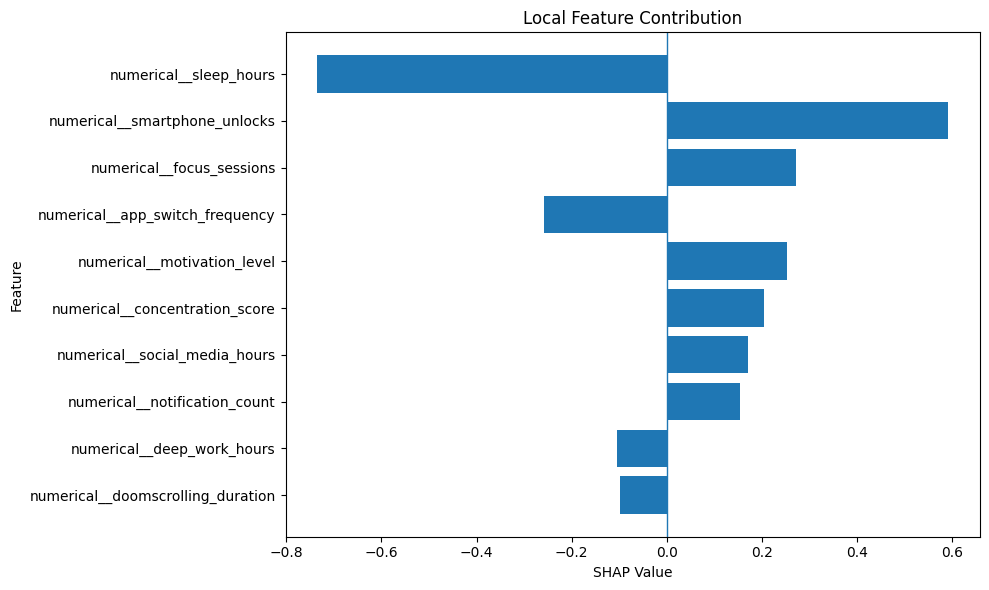

In [43]:
plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top10_contribution["Feature"],
    top10_contribution["SHAP Value"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.gca().invert_yaxis()

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Local Feature Contribution"
)

plt.tight_layout()

plt.show()

In [44]:
positive_feature = feature_contribution[
    feature_contribution["Direction"] == "Positive"
]

negative_feature = feature_contribution[
    feature_contribution["Direction"] == "Negative"
]

print(
    "Positive Features:"
)

display(
    positive_feature
)

print(
    "Negative Features:"
)

display(
    negative_feature
)

Positive Features:


,Rank,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
1,2,numerical__smartphone_unlocks,0.6240,0.5919,Positive,0.5919
2,3,numerical__focus_sessions,1.2530,0.2712,Positive,0.2712
4,5,numerical__motivation_level,-1.0966,0.2520,Positive,0.2520
5,6,numerical__concentration_score,0.7153,0.2036,Positive,0.2036
6,7,numerical__social_media_hours,0.0360,0.1697,Positive,0.1697
7,8,numerical__notification_count,-0.1468,0.1544,Positive,0.1544
11,12,numerical__task_completion_rate,0.7796,0.0790,Positive,0.0790
13,14,numerical__distraction_frequency,0.2944,0.0284,Positive,0.0284
14,15,numerical__late_night_device_usage,0.3554,0.0079,Positive,0.0079


Negative Features:


,Rank,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
0,1,numerical__sleep_hours,1.6605,-0.7353,Negative,0.7353
3,4,numerical__app_switch_frequency,-1.2566,-0.2589,Negative,0.2589
8,9,numerical__deep_work_hours,1.4043,-0.1049,Negative,0.1049
9,10,numerical__doomscrolling_duration,-0.4784,-0.0990,Negative,0.0990
10,11,numerical__sleep_quality,-1.1248,-0.0806,Negative,0.0806
12,13,numerical__daily_screen_time,0.1330,-0.0356,Negative,0.0356


Kết quả Local Feature Contribution cho thấy quyết định dự đoán của mô hình được hình thành từ sự kết hợp giữa các đặc trưng có tác động tích cực và tiêu cực.

Đối với quan sát được lựa chọn, **Smartphone Unlocks** là đặc trưng có mức đóng góp tích cực lớn nhất, góp phần làm tăng khả năng mô hình dự đoán quan sát thuộc **Class 1**. Ngược lại, **Sleep Hours** là đặc trưng có mức đóng góp tiêu cực lớn nhất, làm giảm xác suất dự đoán của lớp này.

Ngoài ra, các đặc trưng như **Focus Sessions**, **Motivation Level** và **Concentration Score** tiếp tục hỗ trợ quyết định dự đoán, trong khi **App Switch Frequency**, **Deep Work Hours** và **Doomscrolling Duration** có xu hướng kéo dự đoán theo hướng ngược lại.

Kết quả này cho thấy mô hình không dựa trên một đặc trưng đơn lẻ mà tổng hợp ảnh hưởng của nhiều yếu tố hành vi và học tập để đưa ra quyết định cuối cùng đối với từng sinh viên.

# 4. Research Findings

Phần này tổng hợp các kết quả thu được từ quá trình xây dựng và đánh giá mô hình nhằm rút ra những phát hiện chính của nghiên cứu.

Các kết quả bao gồm:

- Hiệu quả dự đoán của mô hình Machine Learning.
- Những đặc trưng có ảnh hưởng lớn đến Digital Burnout.
- Mức độ nhất quán giữa Feature Validation và Explainable AI.
- Khả năng giải thích dự đoán ở cấp độ cá nhân.

Thông qua đó, nghiên cứu đánh giá mức độ phù hợp của mô hình trong việc dự đoán Digital Burnout và xác định các yếu tố hành vi có ảnh hưởng quan trọng đối với sinh viên.

## 4.1 Model Performance Summary

Tổng hợp kết quả đánh giá các mô hình Machine Learning và xác định mô hình phù hợp nhất cho bài toán dự đoán Digital Burnout.

- Bảng tổng hợp kết quả đánh giá.
- Mô hình được lựa chọn.

In [46]:
performance_table = pd.read_csv(
    "../../models/vietnam_dataset/model_performance.csv"
)

display(
    performance_table
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score
0,Voting Classifier,0.714286,0.774713,0.441379,0.464394,0.661920
1,XGBoost,0.642857,0.517094,0.406553,0.418077,0.612123
2,Logistic Regression,0.663265,0.372487,0.419569,0.388270,0.574410
3,Random Forest,0.693878,0.444288,0.389190,0.380342,0.627028
4,Stacking Classifier,0.704082,0.484043,0.373813,0.350215,0.612333


In [47]:
best_model = performance_table.iloc[0]

display(
    best_model.to_frame(
        name="Value"
    )
)

,Value
Model,Voting Classifier
Accuracy,0.714286
Macro Precision,0.774713
Macro Recall,0.441379
Macro F1-score,0.464394
Weighted F1-score,0.66192


Kết quả đánh giá cho thấy **Voting Classifier** là mô hình có hiệu quả tổng thể cao nhất trên tập Validation và được lựa chọn làm mô hình cuối cùng của nghiên cứu.

Mặc dù một số mô hình như **Random Forest** và **XGBoost** đạt kết quả tốt ở một số chỉ số riêng lẻ, **Voting Classifier** thể hiện sự cân bằng tốt hơn giữa Accuracy, Macro Precision, Macro Recall và Macro F1-score. Điều này cho thấy việc kết hợp nhiều mô hình giúp cải thiện khả năng tổng quát hóa và mang lại hiệu quả dự đoán ổn định hơn đối với dữ liệu khảo sát sinh viên Việt Nam.

Do đó, **Voting Classifier** được sử dụng làm mô hình chính cho các phân tích giải thích (Explainable AI) và các kết quả nghiên cứu tiếp theo.

## 4.2 Key Digital Burnout Drivers

Xác định những đặc trưng có ảnh hưởng lớn nhất đến kết quả dự đoán Digital Burnout dựa trên kết quả Explainable AI.

Nghiên cứu sử dụng giá trị SHAP trung bình của từng đặc trưng để xác định mức độ quan trọng của các yếu tố hành vi sử dụng thiết bị và học tập đối với mô hình dự đoán.

Các đặc trưng được sắp xếp theo giá trị SHAP trung bình giảm dần nhằm xác định các yếu tố đóng vai trò quan trọng nhất trong quá trình dự đoán.

In [48]:
display(
    shap_feature_importance
)

,Feature,Mean_SHAP
0,numerical__app_switch_frequency,0.399335
1,numerical__smartphone_unlocks,0.347211
2,numerical__motivation_level,0.333562
3,numerical__doomscrolling_duration,0.297905
4,numerical__sleep_hours,0.278166
5,numerical__concentration_score,0.249486
6,numerical__sleep_quality,0.216336
7,numerical__daily_screen_time,0.214550
8,numerical__late_night_device_usage,0.211944
9,numerical__deep_work_hours,0.205566


In [49]:
top10_driver = shap_feature_importance.head(
    10
)

display(
    top10_driver
)

,Feature,Mean_SHAP
0,numerical__app_switch_frequency,0.399335
1,numerical__smartphone_unlocks,0.347211
2,numerical__motivation_level,0.333562
3,numerical__doomscrolling_duration,0.297905
4,numerical__sleep_hours,0.278166
5,numerical__concentration_score,0.249486
6,numerical__sleep_quality,0.216336
7,numerical__daily_screen_time,0.214550
8,numerical__late_night_device_usage,0.211944
9,numerical__deep_work_hours,0.205566


In [50]:
print(
    "Top Digital Burnout Drivers"
)

for index, feature in enumerate(

    top10_driver["Feature"],

    start=1

):

    print(
        f"{index}. {feature}"
    )

Top Digital Burnout Drivers
1. numerical__app_switch_frequency
2. numerical__smartphone_unlocks
3. numerical__motivation_level
4. numerical__doomscrolling_duration
5. numerical__sleep_hours
6. numerical__concentration_score
7. numerical__sleep_quality
8. numerical__daily_screen_time
9. numerical__late_night_device_usage
10. numerical__deep_work_hours


Kết quả SHAP Feature Importance cho thấy mô hình chủ yếu dựa trên các đặc trưng phản ánh **hành vi sử dụng thiết bị số**, **khả năng tập trung trong học tập** và **chất lượng nghỉ ngơi** để dự đoán mức độ Digital Burnout.

Các đặc trưng có mức độ ảnh hưởng cao nhất bao gồm **App Switch Frequency**, **Smartphone Unlocks**, **Motivation Level**, **Doomscrolling Duration** và **Sleep Hours**. Đây đều là những yếu tố phản ánh trực tiếp mức độ sử dụng thiết bị, khả năng duy trì sự tập trung và trạng thái phục hồi của sinh viên.

Bên cạnh đó, các đặc trưng như **Concentration Score**, **Sleep Quality**, **Daily Screen Time**, **Deep Work Hours** và **Distraction Frequency** cũng đóng vai trò quan trọng trong quá trình dự đoán, cho thấy Digital Burnout là kết quả của sự kết hợp giữa nhiều khía cạnh hành vi thay vì chỉ phụ thuộc vào một yếu tố riêng lẻ.

Những phát hiện này phù hợp với mục tiêu xây dựng mô hình có khả năng nhận diện các yếu tố ảnh hưởng đến Digital Burnout và cung cấp cơ sở cho việc giải thích kết quả dự đoán của mô hình.

## 4.3 Feature Validation Consistency

Đánh giá mức độ nhất quán giữa các đặc trưng được lựa chọn trong giai đoạn Feature Validation và các đặc trưng quan trọng được xác định bởi Explainable AI.

Các đặc trưng được lựa chọn ở Notebook 04 được đối chiếu với kết quả SHAP Feature Importance nhằm đánh giá:

- Những đặc trưng được xác nhận trực tiếp bởi mô hình.
- Những đặc trưng được biểu diễn thông qua các biến đại diện.
- Những đặc trưng không được sử dụng trong giai đoạn huấn luyện do nguy cơ Target Leakage.

In [51]:
comparison_table = pd.DataFrame({

    "Feature Validation (Notebook 04)": [

        "motivation_level",
        "loss_of_interest",
        "digital_exhaustion",
        "emotional_exhaustion",
        "notification_count",
        "performance_decline",
        "physical_fatigue",
        "sleep_quality",
        "digital_stress",
        "doomscrolling_duration"

    ],

    "Feature trong mô hình cuối": [

        "motivation_level",
        "-",
        "-",
        "-",
        "notification_count",
        "task_completion_rate",
        "sleep_hours, deep_work_hours",
        "sleep_quality",
        "-",
        "doomscrolling_duration"

    ],

    "Consistency": [

        "Direct",
        "Not Used",
        "Not Used",
        "Not Used",
        "Direct",
        "Representative",
        "Representative",
        "Direct",
        "Not Used",
        "Direct"

    ]

})

display(
    comparison_table
)

,Feature Validation (Notebook 04),Feature trong mô hình cuối,Consistency
0,motivation_level,motivation_level,Direct
1,loss_of_interest,-,Not Used
2,digital_exhaustion,-,Not Used
3,emotional_exhaustion,-,Not Used
4,notification_count,notification_count,Direct
5,performance_decline,task_completion_rate,Representative
6,physical_fatigue,"sleep_hours, deep_work_hours",Representative
7,sleep_quality,sleep_quality,Direct
8,digital_stress,-,Not Used
9,doomscrolling_duration,doomscrolling_duration,Direct


In [52]:
consistency_summary = pd.DataFrame({

    "Consistency Type": [

        "Direct Consistency",
        "Representative Consistency",
        "Not Used"

    ],

    "Count": [

        4,
        2,
        4

    ]

})

display(
    consistency_summary
)

,Consistency Type,Count
0,Direct Consistency,4
1,Representative Consistency,2
2,Not Used,4


Kết quả đối chiếu cho thấy quá trình Feature Validation và Explainable AI có mức độ nhất quán cao.

Trong số 10 đặc trưng được lựa chọn ở Notebook 04:

- **04 đặc trưng** được xác nhận trực tiếp trong mô hình cuối (**Motivation Level**, **Notification Count**, **Sleep Quality** và **Doomscrolling Duration**).
- **02 đặc trưng** được biểu diễn thông qua các biến đại diện (**Performance Decline** được phản ánh bởi **Task Completion Rate**; **Physical Fatigue** được phản ánh bởi **Sleep Hours** và **Deep Work Hours**).
- **04 đặc trưng** (**Loss of Interest**, **Digital Exhaustion**, **Emotional Exhaustion** và **Digital Stress**) không được sử dụng trong mô hình huấn luyện do có nguy cơ gây **Target Leakage** hoặc không phù hợp với bộ đặc trưng hành vi đầu vào của mô hình.

Điều này cho thấy mặc dù danh sách đặc trưng ở giai đoạn Feature Validation và mô hình cuối không hoàn toàn giống nhau, các khía cạnh hành vi cốt lõi vẫn được bảo toàn. Đồng thời, việc loại bỏ các đặc trưng có nguy cơ Target Leakage giúp nâng cao khả năng tổng quát hóa và tính tin cậy của mô hình dự đoán.

## 4.4 Personalized Risk Explanation

Minh họa khả năng giải thích của mô hình ở cấp độ cá nhân thông qua việc phân tích một trường hợp cụ thể trong tập Validation.

Kết quả dự đoán của mô hình được kết hợp với giá trị SHAP nhằm xác định các đặc trưng đóng góp tích cực và tiêu cực vào quyết định dự đoán đối với quan sát được lựa chọn.

- Thông tin dự đoán của quan sát.
- Các đặc trưng đóng góp lớn nhất.
- Diễn giải kết quả dự đoán.

In [53]:
# Tóm tắt kết quả dự đoán

prediction_summary = pd.DataFrame({

    "Observation": [
        observation_index
    ],

    "Predicted Class": [
        explained_class
    ],

    "Prediction Probability": [
        round(
            prediction_probability[
                explained_class
            ],
            4
        )
    ]

})

display(
    prediction_summary
)

,Observation,Predicted Class,Prediction Probability
0,0,1,0.7032


In [54]:
top_positive = feature_contribution[

    feature_contribution["Direction"] == "Positive"

].head(5)

display(
    top_positive
)

,Rank,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
1,2,numerical__smartphone_unlocks,0.6240,0.5919,Positive,0.5919
2,3,numerical__focus_sessions,1.2530,0.2712,Positive,0.2712
4,5,numerical__motivation_level,-1.0966,0.2520,Positive,0.2520
5,6,numerical__concentration_score,0.7153,0.2036,Positive,0.2036
6,7,numerical__social_media_hours,0.0360,0.1697,Positive,0.1697


In [55]:
top_negative = feature_contribution[

    feature_contribution["Direction"] == "Negative"

].head(5)

display(
    top_negative
)

,Rank,Feature,Feature Value,SHAP Value,Direction,Absolute SHAP
0,1,numerical__sleep_hours,1.6605,-0.7353,Negative,0.7353
3,4,numerical__app_switch_frequency,-1.2566,-0.2589,Negative,0.2589
8,9,numerical__deep_work_hours,1.4043,-0.1049,Negative,0.1049
9,10,numerical__doomscrolling_duration,-0.4784,-0.0990,Negative,0.0990
10,11,numerical__sleep_quality,-1.1248,-0.0806,Negative,0.0806


Đối với quan sát được lựa chọn, mô hình dự đoán sinh viên thuộc **Class 1** với xác suất khoảng **70%**.

Kết quả Local SHAP cho thấy quyết định này chủ yếu được thúc đẩy bởi các đặc trưng như **Smartphone Unlocks**, **Focus Sessions**, **Motivation Level** và **Concentration Score**, trong khi **Sleep Hours**, **App Switch Frequency** và **Deep Work Hours** là những yếu tố làm giảm xác suất dự đoán của lớp này.

Điều này cho thấy mô hình không chỉ dựa trên một đặc trưng đơn lẻ mà tổng hợp ảnh hưởng của nhiều hành vi sử dụng thiết bị và học tập để đưa ra quyết định cuối cùng. Kết quả cũng minh họa khả năng giải thích ở cấp độ cá nhân của mô hình, giúp xác định các yếu tố ảnh hưởng mạnh nhất đối với từng sinh viên cụ thể.

# 5. Export Results

Lưu các kết quả Explainable AI nhằm phục vụ quá trình phân tích, trực quan hóa và xây dựng Dashboard.

- SHAP Feature Importance
- Local Feature Contribution
- Prediction Summary

In [56]:
from pathlib import Path

output_dir = Path(
    "../../results/vietnam_dataset"
)

output_dir.mkdir(

    parents=True,

    exist_ok=True

)

In [57]:
shap_feature_importance.to_csv(

    output_dir / "shap_feature_importance.csv",

    index=False

)

feature_contribution.to_csv(

    output_dir / "local_feature_contribution.csv",

    index=False

)

prediction_summary.to_csv(

    output_dir / "prediction_summary.csv",

    index=False

)

print(
    "Export completed."
)

Export completed.


In [58]:
print(
    "Saved files:"
)

for file in output_dir.iterdir():

    print(
        file.name
    )

Saved files:
local_feature_contribution.csv
prediction_summary.csv
shap_feature_importance.csv
